# 篇末综合 等总量输入的不同过程

## 学习目标与先修知识

能独立比较等总量输入（input）方案，核验收支（mass balance）与误差，解释输入时序怎样影响峰值和终值。

先修：本篇四章：递推、微积分、一阶模型（model）和分段数值验证。 [复习上一节](../04-数值模拟误差与迁移/03-在输入跳变处分段计算.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

共同起点 A0=0、清除系数（elimination rate constant） k=0.5/T、观察到 4 T。把总计 4 U 的输入安排在前半段、后半段或全程均匀，峰值与终值是否相同？先检查总量，再检验轨迹（trajectory），最后解释差别。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()

## 初步实验

先按给定条件计算，再用后面的推导解释结果。

In [2]:
bounds=[0,2,4]
plans={'Early':[2,0],'Late':[0,2],'Even':[1,1]}
for name,rates in plans.items():
    total=sum((b-a)*r for a,b,r in zip(bounds,bounds[1:],rates))
    print(name,': total =',total,'U')

Early : total = 4 U
Late : total = 4 U
Even : total = 4 U


## 模型假设

比较对象只改变输入发生的时刻。边界、初值（initial condition）、k、观察区间和误差指标相同；输入均为有限分段恒定速率，不包含瞬时注入。模型保持非负、线性、均匀混合。

## 数学解释与推导

总输入量为 $I=\sum_j u_j(b_{j+1}-b_j)$。等 I 只固定面积，清除会继续对早已进入的物质起作用，所以不能由总量直接推出最终保留量。

本题对每个方案同时报告：I、解析峰值、解析终值、欧拉法（forward Euler method）步长 h 的最大误差和 h/2 的最大误差。峰值不是某个随意采样点的最大值：本模型每段的偏离都按指数单调趋向平衡（equilibrium），故段内不会超过两端的较大值。网格包含所有分段端点，因此其**解析参考**最大值就是整个区间的真实峰值。

前半段方案在 t=2 达峰，$A(2)=4(1-e^{-1})$，然后衰减为 $A(4)=4(1-e^{-1})e^{-1}$。后半段方案的峰值相同，但峰值发生在终点。均匀方案一直上升到 $2(1-e^{-2})$。这些式子给出独立于欧拉循环的比较依据。

零清除是重要反例：三方案终值都等于 4 U，但中间轨迹仍不同。若只报告终值，就会漏掉过程差异。实际问题应先由研究问题确定峰值、终值或其他指标，而非观察完结果再挑有利指标。

## 核心实现

函数只接收本节定义的量；核心计算步骤如下。

In [3]:
def aligned_grid(bounds, h):
    import math
    times = [bounds[0]]
    for left, right in zip(bounds, bounds[1:]):
        count = math.ceil((right - left) / h - 1e-12)
        for i in range(1, count + 1):
            # Restart at each change point, keeping the exact final boundary.
            times.append(right if i == count else left + i * h)
    return times

def exact_amount(time, u, k, A0):
    import math
    if k == 0:
        return A0 + u * time
    # expm1(z)/z tends to 1; this avoids both cancellation and a huge u/k.
    z = -k * time
    ratio = 1.0 if z == 0 else math.expm1(z) / z
    return A0 * math.exp(z) + u * time * ratio

def exact_series(A0, u, k, times):
    return [exact_amount(t, u, k, A0) for t in times]

def piecewise(A0, k, bounds, rates, h):
    times = aligned_grid(bounds, h)
    amounts, reference = [A0], [A0]
    segment = 0
    exact_at_start = A0
    for left, right in zip(times, times[1:]):
        if segment + 1 < len(rates) and left >= bounds[segment + 1] - 1e-12:
            exact_at_start = exact_amount(bounds[segment + 1] - bounds[segment],
                                          rates[segment], k, exact_at_start)
            segment += 1
        rate = rates[segment]
        duration = right - left
        amounts.append(amounts[-1] + duration * (rate - k * amounts[-1]))
        reference.append(exact_amount(right - bounds[segment], rate, k, exact_at_start))
    return times, amounts, reference

def compare_input(A0, k, bounds, rates, h):
    _, amounts, reference = piecewise(A0, k, bounds, rates, h)
    _, finer, fine_reference = piecewise(A0, k, bounds, rates, h / 2)
    total = sum((b - a) * rate for a, b, rate in zip(bounds, bounds[1:], rates))
    error = max(abs(a - b) for a, b in zip(amounts, reference))
    fine_error = max(abs(a - b) for a, b in zip(finer, fine_reference))
    return total, max(reference), reference[-1], error, fine_error

def input_totals(bounds, plans):
    totals = []
    for rates in plans:
        totals.append(sum((b - a) * rate for a, b, rate in zip(bounds, bounds[1:], rates)))
    return totals

## 对照实验

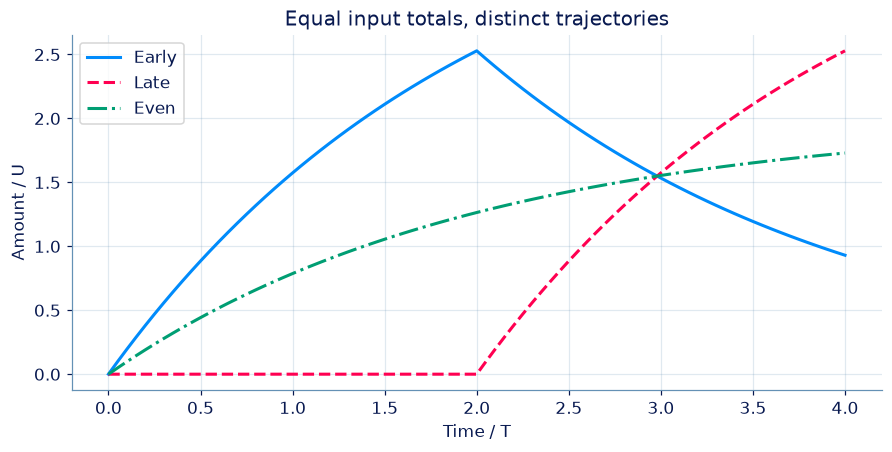

| 方案 | 总输入 / U | 解析峰值 / U | 解析终值 / U | h=.5 误差 / U | h=.25 误差 / U |
| --- | --- | --- | --- | --- | --- |
| Early | 4 | 2.52848 | 0.930177 | 0.205893 | 0.0970821 |
| Late | 4 | 2.52848 | 2.52848 | 0.205893 | 0.0970821 |
| Even | 4 | 1.72933 | 1.72933 | 0.102946 | 0.0485411 |

In [4]:
fig,ax=plt.subplots()
rows=[]
for (name,rates),style in zip(plans.items(),['-','--','-.']):
    times,amounts,reference=piecewise(0,.5,bounds,rates,.05)
    ax.plot(times,reference,style,label=name)
    rows.append((name,*compare_input(0,.5,bounds,rates,.5)))
ax.set(xlabel='Time / T',ylabel='Amount / U',title='Equal input totals, distinct trajectories');ax.legend();plt.show()
display(Markdown(show_table(['方案','总输入 / U','解析峰值 / U','解析终值 / U','h=.5 误差 / U','h=.25 误差 / U'],rows)))

## 结果解释

前置与后置输入的峰值相同，发生时刻却不同；前置输入在终点保留得更少。全程均匀输入的峰值更低，终值位于另两者之间。表格同时给误差，避免用未经核验的粗网格差异解释机制。结论仅针对当前线性清除模型与这些比较条件。

### 独立核对

先核对每个方案的输入总量和收支，再分别比较峰值、终值与误差。不同指标回答不同问题，方案排序也可能随目标改变。

In [5]:
expected_final={'Early':4*(1-math.exp(-1))*math.exp(-1),'Late':4*(1-math.exp(-1)),'Even':2*(1-math.exp(-2))}
for name,rates in plans.items():
    total,peak,final,error,fine=compare_input(0,.5,bounds,rates,.5)
    assert math.isclose(total,4)
    assert math.isclose(final,expected_final[name],abs_tol=1e-12)
    assert fine<error
    assert math.isclose(compare_input(0,0,bounds,rates,.5)[2],4)
assert input_totals(bounds,list(plans.values()))==[4,4,4]
print('等总量、独立终值、误差细化和零清除反例均通过。')

等总量、独立终值、误差细化和零清除反例均通过。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 单项选择题：先把速率写进更新式

单室模型（one-compartment model）以 A 表示所追踪物质总量（tracked amount）（U），u 表示流入速率（U/T），k 表示清除系数（elimination rate constant）（1/T）。在一段实际时长 Δt 内用段首状态（state）计算变化。哪一项是本篇的欧拉更新？

- **A.** A_next=A+u−kA。
- **B.** A_next=A+u×Δt−kA。
- **C.** A_next=A+(u−kA)×Δt。
- **D.** A_next=(A+u−k)×Δt。

[作答：先把速率写进更新式](http://127.0.0.1:8000/parts/02-%E7%B3%BB%E7%BB%9F%E9%9A%8F%E6%97%B6%E9%97%B4%E6%BC%94%E5%8C%96/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p02-cap-rate-balance)

### 第 2 题 · 基础辨析 · 10 分 · 多项选择题：等总量为何不等轨迹

从零开始，k=0.5 /T，观察 0—4 T；三个输入（input）分别为前 2 T 以 2 U/T、后 2 T 以 2 U/T、全程 1 U/T。哪些结论正确？

- **A.** 总流入都为 4 U。
- **B.** 三者最终所追踪物质总量（tracked amount）必然相等。
- **C.** 较早进入的物质有更长时间被清除。
- **D.** 若改为 k=0，三者终值相同，但中间过程仍可不同。

[作答：等总量为何不等轨迹](http://127.0.0.1:8000/parts/02-%E7%B3%BB%E7%BB%9F%E9%9A%8F%E6%97%B6%E9%97%B4%E6%BC%94%E5%8C%96/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p02-equal-area-not-path)

### 第 3 题 · 方法应用 · 15 分 · Python 计算题：先确认比较方案的总量相同

三种人工输入（input）方案使用相同的分段边界。分别计算每个方案的累计输入量，作为公平比较的第一项检查。这里只累计流入，不扣清除。

**函数与代码模板**

```python
def solve(
    bounds: list[float],
    plans: list[list[float]],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `bounds` | `list[float]` | 共同的严格递增分段边界，首项 0。 | T |
| `plans` | `list[list[float]]` | 每行是一种方案的分段流入速率。 | U/T |

**返回值**

直接返回 totals（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `totals` | `list[float]` | 按方案顺序返回总流入量。 | U |

**计算规则**

对每行 rates，返回 sum((bounds[j+1]−bounds[j])*rates[j])。

**约束与边界**

- 所有数值有限；无需修改输入。
- 2—20 个边界，末点≤20；1—10 个方案，每行长度为 len(bounds)−1；0≤rate≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| bounds | 共同的严格递增分段边界，首项 0。 | [0, 2, 4] | T |
| plans | 每行是一种方案的分段流入速率。 | [[2, 0], [0, 2], [1, 1]] | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
bounds = [0, 2, 4]
plans = [[2, 0], [0, 2], [1, 1]]

result = solve(bounds, plans)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| totals | 按方案顺序返回总流入量。 | [4, 4, 4] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [4, 4, 4]
```

**样例解释**

三个方案分别为 2×2、2×2、1×2+1×2，总量都为 4 U。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：先确认比较方案的总量相同](http://127.0.0.1:8000/parts/02-%E7%B3%BB%E7%BB%9F%E9%9A%8F%E6%97%B6%E9%97%B4%E6%BC%94%E5%8C%96/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p02-input-totals)

### 第 4 题 · 方法应用 · 15 分 · Python 计算题：用累计量核对连续收支

给定各段恒定输入（input）和边界时刻的所追踪物质总量（tracked amount），计算总输入、存量（stock）净变化与累计清除量。忽略其他来源与损失，数据满足非负清除；累计清除量由整段收支（mass balance）确定，不等于末时刻清除速率。

**函数与代码模板**

```python
def solve(
    bounds: list[float],
    rates: list[float],
    amounts: list[float],
) -> tuple[float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `bounds` | `list[float]` | 严格递增的段边界，首项为 0。 | T |
| `rates` | `list[float]` | 各段恒定流入速率。 | U/T |
| `amounts` | `list[float]` | 每个边界时刻的总量。 | U |

**返回值**

按以下顺序返回元组：(total_input, change, removed)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `total_input` | `float` | 全部时段的累计流入量。 | U |
| `change` | `float` | 末总量减起点总量。 | U |
| `removed` | `float` | 按收支推得的累计清除量。 | U |

**计算规则**

总输入 = 各段速率×实际时长之和；净变化 = amounts[-1]−amounts[0]；累计清除 = 总输入−净变化。

**约束与边界**

- 所有数值均为有限数；无需修改输入。
- 2—100 个边界，末点≤100；amounts 与 bounds 等长，rates 少一项。
- 0≤rates[i],amounts[i]≤100；每段收支推得的清除量非负。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| bounds | 严格递增的段边界，首项为 0。 | [0, 1, 3] | T |
| rates | 各段恒定流入速率。 | [2, 1] | U/T |
| amounts | 每个边界时刻的总量。 | [1, 2, 2.5] | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
bounds = [0, 1, 3]
rates = [2, 1]
amounts = [1, 2, 2.5]

result = solve(bounds, rates, amounts)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| total_input | 全部时段的累计流入量。 | 4 | U |
| change | 末总量减起点总量。 | 1.5 | U |
| removed | 按收支推得的累计清除量。 | 2.5 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (4, 1.5, 2.5)
```

**样例解释**

总输入为 2×1+1×2=4 U；净变化为 2.5−1=1.5 U；累计清除为 4−1.5=2.5 U。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：用累计量核对连续收支](http://127.0.0.1:8000/parts/02-%E7%B3%BB%E7%BB%9F%E9%9A%8F%E6%97%B6%E9%97%B4%E6%BC%94%E5%8C%96/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p02-cap-integrated-balance)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：解释方案差异前先核验误差

对一种分段恒定输入（piecewise constant input）方案，计算总流入量、解析峰值和终值，以及两种步长下的欧拉法（forward Euler method）最大误差。该模型（model）每个恒定输入（input）段内单调，因此解析峰值可在各段端点找到。

**函数与代码模板**

```python
def solve(
    A0: float,
    k: float,
    bounds: list[float],
    rates: list[float],
    h: float,
) -> tuple[float, float, float, float, float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A0` | `float` | 共同起点所追踪物质总量（tracked amount）。 | U |
| `k` | `float` | 非负清除系数（elimination rate constant）。 | 1/T |
| `bounds` | `list[float]` | 严格递增边界，首项 0。 | T |
| `rates` | `list[float]` | 各段非负输入速率。 | U/T |
| `h` | `float` | 较粗网格名义步长。 | T |

**返回值**

按以下顺序返回元组：(total, peak, final, error, fine_error)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `total` | `float` | 总输入量。 | U |
| `peak` | `float` | 分段解析轨迹（trajectory）的峰值，包括起点。 | U |
| `final` | `float` | 分段解析终值。 | U |
| `error` | `float` | 步长 h 的欧拉网格最大误差。 | U |
| `fine_error` | `float` | 步长 h/2 的欧拉网格最大误差。 | U |

**计算规则**

使用本篇跳变对齐网格分别运行 h 与 h/2；误差在各自网格上相对分段解析解（analytical solution）计算。peak、final 来自解析参考，不取未验证的欧拉峰值。

**约束与边界**

- 所有数值有限；无需修改输入。
- 0≤A0,rates[j]≤20；0≤k≤2；2—20 个边界，末点≤20，相邻间隔≥1e−4；rates 比 bounds 少一项；0.02≤h≤4，总步数≤10000。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A0 | 共同起点所追踪物质总量（tracked amount）。 | 0 | U |
| k | 非负清除系数（elimination rate constant）。 | 0.5 | 1/T |
| bounds | 严格递增边界，首项 0。 | [0, 2, 4] | T |
| rates | 各段非负输入速率。 | [2, 0] | U/T |
| h | 较粗网格名义步长。 | 0.5 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A0 = 0
k = 0.5
bounds = [0, 2, 4]
rates = [2, 0]
h = 0.5

result = solve(A0, k, bounds, rates, h)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| total | 总输入量。 | 4 | U |
| peak | 分段解析轨迹（trajectory）的峰值，包括起点。 | ≈ 2.528482 | U |
| final | 分段解析终值。 | ≈ 0.9301766 | U |
| error | 步长 h 的欧拉网格最大误差。 | ≈ 0.2058928 | U |
| fine_error | 步长 h/2 的欧拉网格最大误差。 | ≈ 0.0970821 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (4,
                   2.5284822353142307,
                   0.9301766317393185,
                   0.20589276468576934,
                   0.09708210146250273)
```

**样例解释**

总流入 4 U；输入结束时达到峰值 4(1−exp(−1))≈2.5284822353 U，之后衰减到约 0.9301766317 U。误差需分别由两次网格计算。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：解释方案差异前先核验误差](http://127.0.0.1:8000/parts/02-%E7%B3%BB%E7%BB%9F%E9%9A%8F%E6%97%B6%E9%97%B4%E6%BC%94%E5%8C%96/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p02-input-metrics)

### 第 6 题 · 综合验证 · 15 分 · 多项选择题：哪些证据足以交付迁移实验

将恒定输入（input）改成分段输入后，哪些检查属于本例应保留的独立核验？

- **A.** 确认网格包含每个跳变且用实际 dt 更新。
- **B.** 只看最后一幅曲线是否光滑。
- **C.** 用分段解析解（analytical solution）比较，并检查 k=0 的累计输入边界。
- **D.** 比较 h 与 h/2 的误差，报告失败情形。

[作答：哪些证据足以交付迁移实验](http://127.0.0.1:8000/parts/02-%E7%B3%BB%E7%BB%9F%E9%9A%8F%E6%97%B6%E9%97%B4%E6%BC%94%E5%8C%96/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p02-migration-evidence)

### 第 7 题 · 迁移挑战 · 10 分 · Python 计算题：迁移到带过程上限的方案筛选

沿用一阶清除模型（model） dA/dt=u−kA，现要求候选方案同时满足指定总输入（input）、输入速率上限和全程所追踪物质总量（tracked amount）上限。每个方案独立从 A0 开始，返回所有满足要求的方案索引。

**函数与代码模板**

```python
def solve(
    bounds: list[float],
    plans: list[list[float]],
    k: float,
    A0: float,
    required_total: float,
    max_rate: float,
    max_peak: float,
) -> list[int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `bounds` | `list[float]` | 各方案共同的严格递增分段边界，首项 0。 | T |
| `plans` | `list[list[float]]` | 每行一个方案的分段恒定输入（piecewise constant input）速率。 | U/T |
| `k` | `float` | 清除系数（elimination rate constant），所有方案相同。 | 1/T |
| `A0` | `float` | 每个方案的共同起点总量。 | U |
| `required_total` | `float` | 要求的总输入量。 | U |
| `max_rate` | `float` | 任何时段的输入速率上限。 | U/T |
| `max_peak` | `float` | 包括起点在内的全程总量上限。 | U |

**返回值**

直接返回 indices（list[int]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `indices` | `list[int]` | 合格方案的从 0 开始索引，按原顺序排列；无合格方案时为空列表。 | 无量纲 |

**计算规则**

先计算各方案的累计输入，再用每段解析传播核对全程峰值。恒定输入的单室轨迹（trajectory）每段单调，峰值取起点与各分段端点的最大值。总输入与 required_total 的绝对差≤1e−9，速率与峰值分别≤对应上限+1e−9 才合格。k=0 用线性积累；k 很小时注意指数差的精度。

**约束与边界**

- 所有数值均为有限数；无需修改输入。
- 2—20 个边界，末点≤20，相邻间隔≥1e−4；0—10 个方案，每行比 bounds 少一项。
- 0≤A0,rates[i],max_rate,max_peak≤20；0≤k≤2；0≤required_total≤400。
- 峰值包括初始时刻；三项条件必须同时满足，不能只检查终值或总输入。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| bounds | 各方案共同的严格递增分段边界，首项 0。 | [0, 2, 4] | T |
| plans | 每行一个方案的分段恒定输入（piecewise constant input）速率。 | [[2, 0], [0, 2], [1, 1]] | U/T |
| k | 清除系数（elimination rate constant），所有方案相同。 | 0.5 | 1/T |
| A0 | 每个方案的共同起点总量。 | 0 | U |
| required_total | 要求的总输入量。 | 4 | U |
| max_rate | 任何时段的输入速率上限。 | 2 | U/T |
| max_peak | 包括起点在内的全程总量上限。 | 2 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
bounds = [0, 2, 4]
plans = [[2, 0], [0, 2], [1, 1]]
k = 0.5
A0 = 0
required_total = 4
max_rate = 2
max_peak = 2

result = solve(bounds, plans, k, A0, required_total, max_rate, max_peak)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| indices | 合格方案的从 0 开始索引，按原顺序排列；无合格方案时为空列表。 | [2] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2]
```

**样例解释**

三方案总输入均为 4 U，最大速率均不超过 2 U/T。前置和后置的峰值约 2.5284822353 U，均超过 2 U；均匀输入峰值约 1.7293294335 U，故返回 [2]。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：迁移到带过程上限的方案筛选](http://127.0.0.1:8000/parts/02-%E7%B3%BB%E7%BB%9F%E9%9A%8F%E6%97%B6%E9%97%B4%E6%BC%94%E5%8C%96/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p02-cap-feasible-plans)

### 第 8 题 · 迁移挑战 · 10 分 · 多项选择题：改变约束后重新解释方案

从 A0=0 开始，k=0.5/T，观察 4 T。前置、后置、均匀三个方案总输入（input）均为 4 U，速率都不超过 2 U/T。独立解析计算给出峰值约 2.528、2.528、1.729 U，终值约 0.930、2.528、1.729 U。若全程上限为 2 U，哪些判断正确？

- **A.** 在声明模型（model）与这些条件下，只有均匀方案满足全程上限。
- **B.** 前置方案终值最低，所以必然满足全程上限。
- **C.** 若只将 k 改为 0，三个方案终值均为 4 U，因此都超过原上限。
- **D.** 筛选计算正确，就足以把同样参数（parameter）直接用作真实个体的干预方案。

[作答：改变约束后重新解释方案](http://127.0.0.1:8000/parts/02-%E7%B3%BB%E7%BB%9F%E9%9A%8F%E6%97%B6%E9%97%B4%E6%BC%94%E5%8C%96/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p02-model-scope)

**进一步阅读**

[MIT 一阶微分方程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-i-first-order-differential-equations/)：分段与输入响应的数学背景；[SciPy 求解器文档](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)：进一步的方法与误差控制。